## Imports

In [12]:
import os

import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    TextVectorization,
    Embedding,
    Dense,
    SimpleRNN,
    LSTM,
    GRU,
    RNN,
    SimpleRNNCell,
    Bidirectional,
    Dropout,
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split

In [13]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 10)

In [14]:
if not os.path.exists("models"):
    os.makedirs("models")

In [15]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

## Utils

In [16]:
def plot_history(history, title="Model Performance"):
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history["accuracy"], label="train")
    ax1.plot(history.history["val_accuracy"], label="validation")
    ax1.set_title(f"{title} - Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()

    ax2.plot(history.history["loss"], label="train")
    ax2.plot(history.history["val_loss"], label="validation")
    ax2.set_title(f"{title} - Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()

    plt.tight_layout()
    plt.show()

In [17]:
def build_model(rnn_type="SimpleRNN"):
    model = Sequential()

    model.add(Input(shape=(max_len,), dtype="int32"))
    model.add(Embedding(input_dim=max_tokens + 1, output_dim=128))

    if rnn_type == "SimpleRNN":
        model.add(Bidirectional(SimpleRNN(64)))
    elif rnn_type == "LSTM":
        model.add(Bidirectional(LSTM(64)))
    elif rnn_type == "GRU":
        model.add(Bidirectional(GRU(64)))

    model.add(Dropout(0.5))
    model.add(Dense(64, activation="relu"))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

In [18]:
def predict(model, sample_texts, sample_x, sample_labels_true, num_samples, title):

    print("Generating predictions...")
    preds_model = model.predict(sample_x, verbose=0)

    for i in range(num_samples):
        text_snippet = sample_texts[i].replace("\n", " ")
        if len(text_snippet) > 80:
            text_snippet = text_snippet[:80] + "..."

        true_sentiment = "Positive" if sample_labels_true[i] == 1.0 else "Negative"

        model_val = preds_model[i][0]

        model_sentiment = "Positive" if model_val > 0.5 else "Negative"

        print(f"\n[Sample {i+1}] Text: '{text_snippet}'")
        print(f"  - True Label : {true_sentiment}")
        print(f"  - {title}  : {model_sentiment:<8} (Confidence: {model_val:.4f})")

## Dataload

In [19]:
print("Loading data from CSV...")
df = pd.read_csv("../data/IMDB Dataset.csv")

df.info()

Loading data from CSV...
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [20]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [21]:
review_word_count = df["review"].str.split().str.len()

review_word_count.describe()

count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review, dtype: float64

<Axes: >

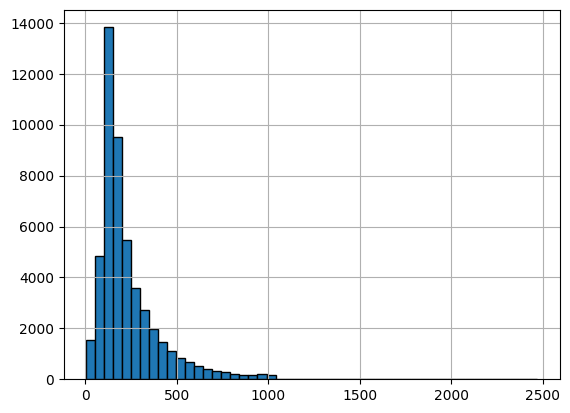

In [22]:
review_word_count.hist(bins=50, edgecolor="black")

In [23]:
texts = df["review"].astype(str).tolist()
labels = np.where(
    df["sentiment"].astype(str).str.lower().str.strip() == "positive", 1.0, 0.0
).astype(np.float32)

print("Splitting data into train, validation, and test sets...")
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

Splitting data into train, validation, and test sets...


In [24]:
max_tokens = 10000
max_len = 500

vectorize_layer = TextVectorization(
    max_tokens=max_tokens, output_mode="int", output_sequence_length=max_len
)

print("Adapting TextVectorization layer to the training vocabulary...")
vectorize_layer.adapt(train_texts)

print("Pre-vectorizing the text data...")
train_x = vectorize_layer(train_texts)
val_x = vectorize_layer(val_texts)
test_x = vectorize_layer(test_texts)

train_y = tf.constant(train_labels)
val_y = tf.constant(val_labels)
test_y = tf.constant(test_labels)

E0000 00:00:1778575098.271270    4009 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1778575098.782216    4009 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Adapting TextVectorization layer to the training vocabulary...
Pre-vectorizing the text data...


## Training

In [25]:
epochs_to_run = 10
batch_size = 256

custom_reviews = [
    "This movie was an absolute triumph. The direction was brilliant and the acting was top notch.",
    "I regret spending money on this. The plot made no sense and it was incredibly boring.",
]

custom_reviews_vectorized = vectorize_layer(custom_reviews)

num_samples = 10
sample_texts = test_texts[:num_samples]
sample_labels_true = test_labels[:num_samples]
sample_x = vectorize_layer(sample_texts)

### SimpleRNN

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 57s 350ms/step - accuracy: 0.5476 - loss: 0.6835 - val_accuracy: 0.5878 - val_loss: 0.6712
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 54s 346ms/step - accuracy: 0.6563 - loss: 0.6190 - val_accuracy: 0.7748 - val_loss: 0.4876
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 81s 344ms/step - accuracy: 0.7984 - loss: 0.4650 - val_accuracy: 0.8142 - val_loss: 0.4577
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 53s 340ms/step - accuracy: 0.8634 - loss: 0.3394 - val_accuracy: 0.7778 - val_loss: 0.5309
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 53s 339ms/step - accuracy: 0.9008 - loss: 0.2524 - val_accuracy: 0.7878 - val_loss: 0.6983
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 54s 341ms/step - accuracy: 0.9383 - loss: 0.1696 - val_accuracy: 0.7772 - val_loss: 0.8033

Evaluating SimpleRNN on Test Data...
Test Accuracy: 0.8224


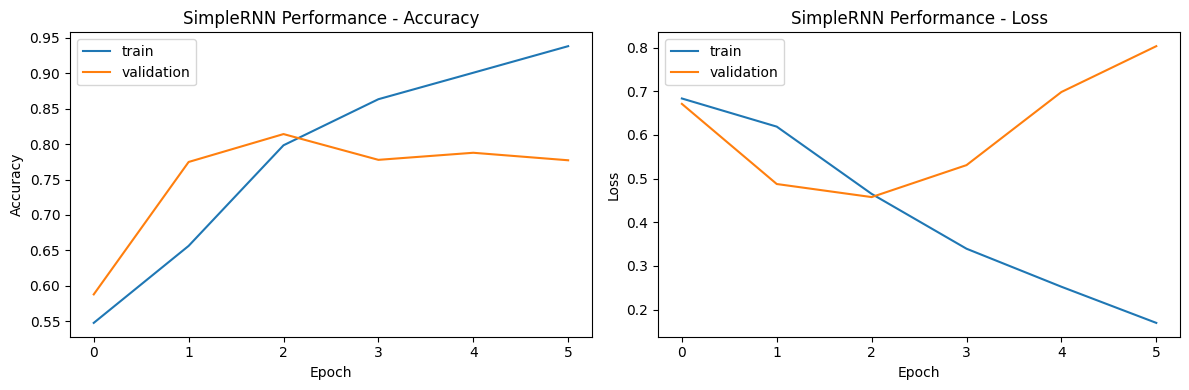

In [26]:
model_rnn = build_model(rnn_type="SimpleRNN")

early_stop_rnn = EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)
checkpoint_rnn = ModelCheckpoint(
    filepath="models/best_model_SimpleRNN.keras",
    monitor="val_loss",
    save_best_only=True,
)

history_rnn = model_rnn.fit(
    x=train_x,
    y=train_y,
    validation_data=(val_x, val_y),
    epochs=epochs_to_run,
    batch_size=batch_size,
    callbacks=[early_stop_rnn, checkpoint_rnn],
)

print(f"\nEvaluating SimpleRNN on Test Data...")
loss, acc = model_rnn.evaluate(test_x, test_y, batch_size=batch_size, verbose=0)
print(f"Test Accuracy: {acc:.4f}")

plot_history(history_rnn, title="SimpleRNN Performance")

In [27]:
print(f"\nTest samples predictions:")
predict(
    model_rnn,
    sample_texts,
    sample_x,
    sample_labels_true,
    num_samples,
    title="SimpleRNN Prediction",
)

print(f"\nCustom Predictions:")
predictions = model_rnn.predict(custom_reviews_vectorized, verbose=0)
for review, pred in zip(custom_reviews, predictions):
    print(
        f"Review: '{review[:50]}...' -> {'Positive' if pred[0] > 0.5 else 'Negative'} ({pred[0]:.4f})"
    )


Test samples predictions:
Generating predictions...

[Sample 1] Text: 'the tortuous emotional impact is degrading, whether adult or adolescent the pers...'
  - True Label : Negative
  - SimpleRNN Prediction  : Negative (Confidence: 0.3971)

[Sample 2] Text: 'Anyone who knows anything about evolution wouldn't even need to see the film to ...'
  - True Label : Negative
  - SimpleRNN Prediction  : Negative (Confidence: 0.0694)

[Sample 3] Text: 'I'm glad I rented this movie for one reason: its shortcomings made me want to re...'
  - True Label : Negative
  - SimpleRNN Prediction  : Negative (Confidence: 0.2721)

[Sample 4] Text: 'Yes, the votes are in. This film may very well be the Plan 9 From Outer Space fo...'
  - True Label : Negative
  - SimpleRNN Prediction  : Negative (Confidence: 0.2814)

[Sample 5] Text: 'This mini-series is actually more entertaining than some others with much bigger...'
  - True Label : Negative
  - SimpleRNN Prediction  : Negative (Confidence: 0.3108)

[Sampl

### LSTM

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 120s 748ms/step - accuracy: 0.7577 - loss: 0.4803 - val_accuracy: 0.8660 - val_loss: 0.3156
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 115s 734ms/step - accuracy: 0.8935 - loss: 0.2797 - val_accuracy: 0.8852 - val_loss: 0.3032
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 117s 746ms/step - accuracy: 0.8975 - loss: 0.2696 - val_accuracy: 0.8678 - val_loss: 0.3615
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 116s 736ms/step - accuracy: 0.8895 - loss: 0.2811 - val_accuracy: 0.8758 - val_loss: 0.3074
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 117s 744ms/step - accuracy: 0.9325 - loss: 0.1877 - val_accuracy: 0.8692 - val_loss: 0.3378

Evaluating LSTM on Test Data...
Test Accuracy: 0.8878


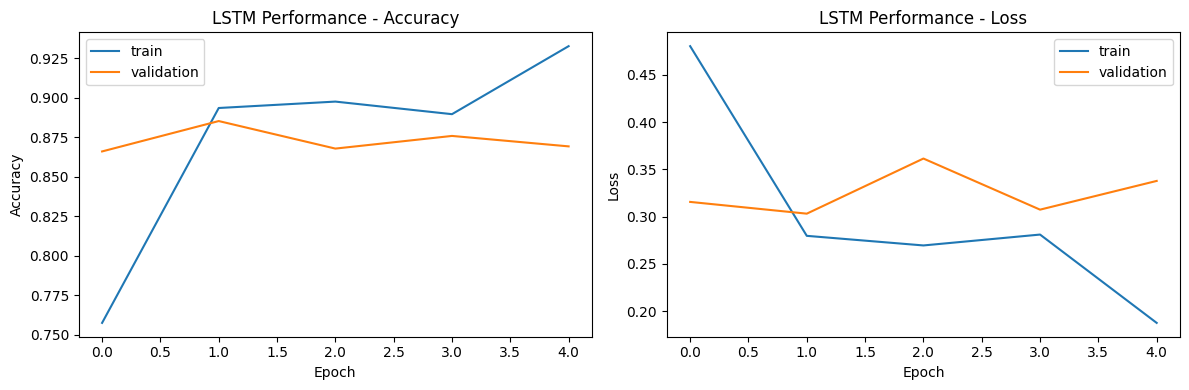

In [28]:
model_lstm = build_model(rnn_type="LSTM")

early_stop_lstm = EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)
checkpoint_lstm = ModelCheckpoint(
    filepath="models/best_model_LSTM.keras", monitor="val_loss", save_best_only=True
)

history_lstm = model_lstm.fit(
    x=train_x,
    y=train_y,
    validation_data=(val_x, val_y),
    epochs=epochs_to_run,
    batch_size=batch_size,
    callbacks=[early_stop_lstm, checkpoint_lstm],
)

print(f"\nEvaluating LSTM on Test Data...")
loss, acc = model_lstm.evaluate(test_x, test_y, batch_size=batch_size, verbose=0)
print(f"Test Accuracy: {acc:.4f}")

plot_history(history_lstm, title="LSTM Performance")

In [29]:
print(f"\nTest samples predictions:")
predict(
    model_lstm,
    sample_texts,
    sample_x,
    sample_labels_true,
    num_samples,
    title="LSTM Prediction",
)

print(f"\nCustom Predictions:")
predictions = model_lstm.predict(custom_reviews_vectorized, verbose=0)
for review, pred in zip(custom_reviews, predictions):
    print(
        f"Review: '{review[:50]}...' -> {'Positive' if pred[0] > 0.5 else 'Negative'} ({pred[0]:.4f})"
    )


Test samples predictions:
Generating predictions...

[Sample 1] Text: 'the tortuous emotional impact is degrading, whether adult or adolescent the pers...'
  - True Label : Negative
  - LSTM Prediction  : Negative (Confidence: 0.0182)

[Sample 2] Text: 'Anyone who knows anything about evolution wouldn't even need to see the film to ...'
  - True Label : Negative
  - LSTM Prediction  : Negative (Confidence: 0.1401)

[Sample 3] Text: 'I'm glad I rented this movie for one reason: its shortcomings made me want to re...'
  - True Label : Negative
  - LSTM Prediction  : Negative (Confidence: 0.2501)

[Sample 4] Text: 'Yes, the votes are in. This film may very well be the Plan 9 From Outer Space fo...'
  - True Label : Negative
  - LSTM Prediction  : Positive (Confidence: 0.9677)

[Sample 5] Text: 'This mini-series is actually more entertaining than some others with much bigger...'
  - True Label : Negative
  - LSTM Prediction  : Negative (Confidence: 0.3125)

[Sample 6] Text: 'For those wit

### GRU

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 126s 785ms/step - accuracy: 0.5919 - loss: 0.6631 - val_accuracy: 0.7124 - val_loss: 0.5619
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 124s 787ms/step - accuracy: 0.8194 - loss: 0.4127 - val_accuracy: 0.8710 - val_loss: 0.3147
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 141s 781ms/step - accuracy: 0.9006 - loss: 0.2647 - val_accuracy: 0.8766 - val_loss: 0.3158
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 124s 792ms/step - accuracy: 0.9193 - loss: 0.2217 - val_accuracy: 0.8842 - val_loss: 0.3031
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 125s 793ms/step - accuracy: 0.9325 - loss: 0.1919 - val_accuracy: 0.8898 - val_loss: 0.3275
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 125s 794ms/step - accuracy: 0.9446 - loss: 0.1623 - val_accuracy: 0.8836 - val_loss: 0.3324
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 123s 782ms/step - accuracy: 0.9553 - loss: 0.1348 - val_accuracy: 0.8826 - val_loss: 0.3666

Evaluating GRU on Test Data...
Test Accuracy: 0.8924


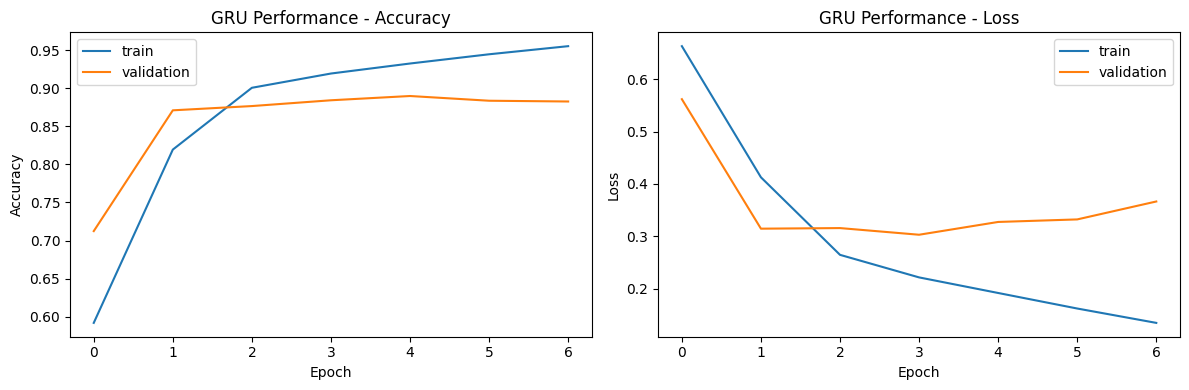

In [30]:
model_gru = build_model(rnn_type="GRU")

early_stop_gru = EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)
checkpoint_gru = ModelCheckpoint(
    filepath="models/best_model_GRU.keras", monitor="val_loss", save_best_only=True
)

history_gru = model_gru.fit(
    x=train_x,
    y=train_y,
    validation_data=(val_x, val_y),
    epochs=epochs_to_run,
    batch_size=batch_size,
    callbacks=[early_stop_gru, checkpoint_gru],
)

print(f"\nEvaluating GRU on Test Data...")
loss, acc = model_gru.evaluate(test_x, test_y, batch_size=batch_size, verbose=0)
print(f"Test Accuracy: {acc:.4f}")

plot_history(history_gru, title="GRU Performance")

In [31]:
print(f"\nTest samples predictions:")
predict(
    model_gru,
    sample_texts,
    sample_x,
    sample_labels_true,
    num_samples,
    title="GRU Prediction",
)

print(f"\nCustom Predictions:")
predictions = model_gru.predict(custom_reviews_vectorized, verbose=0)
for review, pred in zip(custom_reviews, predictions):
    print(
        f"Review: '{review[:50]}...' -> {'Positive' if pred[0] > 0.5 else 'Negative'} ({pred[0]:.4f})"
    )


Test samples predictions:
Generating predictions...

[Sample 1] Text: 'the tortuous emotional impact is degrading, whether adult or adolescent the pers...'
  - True Label : Negative
  - GRU Prediction  : Negative (Confidence: 0.0188)

[Sample 2] Text: 'Anyone who knows anything about evolution wouldn't even need to see the film to ...'
  - True Label : Negative
  - GRU Prediction  : Negative (Confidence: 0.0166)

[Sample 3] Text: 'I'm glad I rented this movie for one reason: its shortcomings made me want to re...'
  - True Label : Negative
  - GRU Prediction  : Negative (Confidence: 0.1622)

[Sample 4] Text: 'Yes, the votes are in. This film may very well be the Plan 9 From Outer Space fo...'
  - True Label : Negative
  - GRU Prediction  : Positive (Confidence: 0.9894)

[Sample 5] Text: 'This mini-series is actually more entertaining than some others with much bigger...'
  - True Label : Negative
  - GRU Prediction  : Negative (Confidence: 0.4781)

[Sample 6] Text: 'For those with acc